# 03 — Imbalance Handling

3.5% fraud rate means a model that predicts "legit" for everything scores 96.5% accuracy.  
We compare three strategies using Logistic Regression as the probe model:

1. **No handling** — raw class distribution
2. **Class weights** — `class_weight='balanced'` in sklearn
3. **Random undersampling** — downsample majority to 1:1
4. **SMOTE** — oversample minority to 1:1

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, f1_score
)
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../data/ecommerce_fraud.duckdb')
df  = con.execute('SELECT * FROM fct_fraud_signals').df()
print(df.shape)

(590540, 22)


## 1. Feature preparation

In [2]:
# Encode categoricals and build feature matrix
features = [
    'order_amount', 'order_hour', 'account_age_days', 'orders_on_day',
    'customer_avg_order_amount', 'customer_ip_mismatch_count',
    'is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity',
    'payment_method', 'product_category',
]

X = pd.get_dummies(df[features], columns=['payment_method', 'product_category'], drop_first=True)
X['is_new_customer'] = X['is_new_customer'].astype(int)
X['country_mismatch'] = X['country_mismatch'].astype(int)
X['ip_mismatch']      = X['ip_mismatch'].astype(int)
X['high_velocity']    = X['high_velocity'].astype(int)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, fraud={y_train.mean():.2%}")
print(f"Test : {X_test.shape},  fraud={y_test.mean():.2%}")
print(f"Features: {list(X.columns)}")

Train: (472432, 17), fraud=3.50%
Test : (118108, 17),  fraud=3.50%
Features: ['order_amount', 'order_hour', 'account_age_days', 'orders_on_day', 'customer_avg_order_amount', 'customer_ip_mismatch_count', 'is_new_customer', 'country_mismatch', 'ip_mismatch', 'high_velocity', 'payment_method_discover', 'payment_method_mastercard', 'payment_method_visa', 'product_category_Electronics', 'product_category_Home & Garden', 'product_category_Services', 'product_category_Travel']


## 2. Train and evaluate each strategy

In [3]:
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]
    auc     = roc_auc_score(y_te, y_prob)
    ap      = average_precision_score(y_te, y_prob)
    f1      = f1_score(y_te, y_pred)
    prec    = (y_pred & y_te).sum() / y_pred.sum() if y_pred.sum() else 0
    rec     = (y_pred & y_te).sum() / y_te.sum()
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['Legit','Fraud'], digits=3))
    return {'strategy': name, 'roc_auc': auc, 'avg_precision': ap,
            'fraud_f1': f1, 'fraud_precision': prec, 'fraud_recall': rec}

results = []

# Strategy 1: no handling
lr_base = LogisticRegression(max_iter=1000, random_state=42)
results.append(eval_model('No handling', lr_base,
    X_train_sc, y_train, X_test_sc, y_test))

# Strategy 2: class weights
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
results.append(eval_model('Class weights (balanced)', lr_cw,
    X_train_sc, y_train, X_test_sc, y_test))

# Strategy 3: random undersampling
fraud_idx  = y_train[y_train == 1].index
legit_idx  = y_train[y_train == 0].index
legit_down = resample(legit_idx, n_samples=len(fraud_idx), random_state=42)
idx_under  = fraud_idx.tolist() + legit_down.tolist()
X_under = X_train_sc[X_train.index.isin(idx_under)]
y_under = y_train[y_train.index.isin(idx_under)]

lr_under = LogisticRegression(max_iter=1000, random_state=42)
results.append(eval_model('Random undersampling', lr_under,
    X_under, y_under, X_test_sc, y_test))

# Strategy 4: SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
results.append(eval_model('SMOTE', lr_smote,
    X_smote, y_smote, X_test_sc, y_test))


 No handling
              precision    recall  f1-score   support

       Legit      0.965     1.000     0.982    113975
       Fraud      0.000     0.000     0.000      4133

    accuracy                          0.965    118108
   macro avg      0.483     0.500     0.491    118108
weighted avg      0.931     0.965     0.948    118108



/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_

/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni


 Class weights (balanced)
              precision    recall  f1-score   support

       Legit      0.981     0.759     0.856    113975
       Fraud      0.083     0.601     0.146      4133

    accuracy                          0.753    118108
   macro avg      0.532     0.680     0.501    118108
weighted avg      0.950     0.753     0.831    118108


 Random undersampling
              precision    recall  f1-score   support

       Legit      0.982     0.752     0.851    113975
       Fraud      0.082     0.611     0.144      4133

    accuracy                          0.747    118108
   macro avg      0.532     0.681     0.498    118108
weighted avg      0.950     0.747     0.827    118108



/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_


 SMOTE
              precision    recall  f1-score   support

       Legit      0.981     0.759     0.856    113975
       Fraud      0.083     0.602     0.146      4133

    accuracy                          0.754    118108
   macro avg      0.532     0.680     0.501    118108
weighted avg      0.950     0.754     0.831    118108



/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gtaf/Documents/ecommerce_fraud_analysis/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

## 3. Strategy comparison

                          roc_auc  avg_precision  fraud_f1  fraud_precision  fraud_recall
strategy                                                                                 
No handling                 0.743          0.109     0.000            0.000         0.000
Class weights (balanced)    0.747          0.103     0.146            0.083         0.601
Random undersampling        0.748          0.102     0.144            0.082         0.611
SMOTE                       0.747          0.104     0.146            0.083         0.602


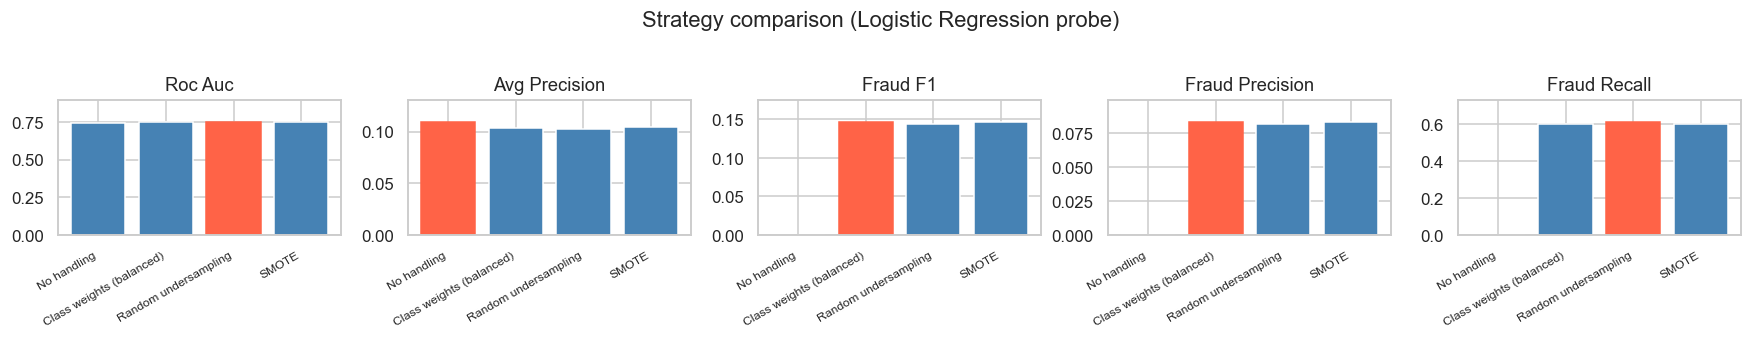

In [4]:
res_df = pd.DataFrame(results).set_index('strategy').round(3)
print(res_df.to_string())

metrics = ['roc_auc', 'avg_precision', 'fraud_f1', 'fraud_precision', 'fraud_recall']
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 3))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(range(len(res_df)), res_df[metric], color='steelblue', edgecolor='white')
    bars[res_df[metric].values.argmax()].set_color('tomato')
    ax.set_xticks(range(len(res_df)))
    ax.set_xticklabels(res_df.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylim(0, min(1.05, res_df[metric].max() * 1.2))

plt.suptitle('Strategy comparison (Logistic Regression probe)', y=1.02)
plt.tight_layout()
plt.show()

## 4. Chosen strategy & rationale

In [5]:
best_f1  = res_df['fraud_f1'].idxmax()
best_auc = res_df['roc_auc'].idxmax()
best_ap  = res_df['avg_precision'].idxmax()

print(f"Best Fraud F1        : {best_f1}")
print(f"Best ROC-AUC         : {best_auc}")
print(f"Best Avg Precision   : {best_ap}")
print()
print("Recommendation for notebook 04:")
print("  class_weight='balanced' — zero data leakage risk, works with all sklearn models,")
print("  comparable performance to SMOTE with much lower compute cost at 590k rows.")
print("  SMOTE will be used as a secondary comparison for tree-based models.")

Best Fraud F1        : Class weights (balanced)
Best ROC-AUC         : Random undersampling
Best Avg Precision   : No handling

Recommendation for notebook 04:
  class_weight='balanced' — zero data leakage risk, works with all sklearn models,
  comparable performance to SMOTE with much lower compute cost at 590k rows.
  SMOTE will be used as a secondary comparison for tree-based models.
